# Computational cost and scalability

This notebook is based on the XAI attribution runner, but it is dedicated only to runtime measurement. It uses T-GARNet as the heaviest evaluated classifier, one representative subject for each MI window, and a comparable ADHD/TDAH fold.


In [15]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Daprosero/STF-KernelSHAP.git"
REPO_NAME = "STF-KernelSHAP"
PACKAGE_PATH = Path("src") / "stf_kernelshap"


def run_command(command, cwd=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        capture_output=True,
    )
    if result.returncode != 0:
        message = [
            f"Command failed: {' '.join(map(str, command))}",
            f"Return code: {result.returncode}",
        ]
        if result.stdout:
            message.append(f"STDOUT:\n{result.stdout}")
        if result.stderr:
            message.append(f"STDERR:\n{result.stderr}")
        raise RuntimeError("\n".join(message))
    return result


def resolve_working_root():
    if Path("/kaggle/working").exists():
        return Path("/kaggle/working")
    if Path("/content").exists():
        return Path("/content")
    return Path.cwd().resolve()


def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / PACKAGE_PATH).exists():
            return candidate

    working_root = resolve_working_root()
    clone_dir = working_root / REPO_NAME

    if (clone_dir / PACKAGE_PATH).exists():
        return clone_dir.resolve()

    if clone_dir.exists() and (clone_dir / ".git").exists():
        run_command(["git", "-C", str(clone_dir), "pull", "--ff-only"])
        if (clone_dir / PACKAGE_PATH).exists():
            return clone_dir.resolve()

    if clone_dir.exists() and not (clone_dir / PACKAGE_PATH).exists():
        clone_dir = working_root / f"{REPO_NAME}_repo"

    if not clone_dir.exists():
        run_command(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])

    if not (clone_dir / PACKAGE_PATH).exists():
        raise FileNotFoundError(
            f"El repositorio clonado no contiene {PACKAGE_PATH}: {clone_dir}"
        )

    return clone_dir.resolve()


def install_project_requirements(project_root):
    requirements_path = project_root / "requirements.txt"
    if not requirements_path.exists():
        raise FileNotFoundError(f"No existe requirements.txt en {project_root}")
    run_command([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_path),
    ])


PROJECT_ROOT = resolve_project_root()
os.chdir(PROJECT_ROOT)

RUNNING_IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or Path("/content").exists()
RUNNING_IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle").exists()
INSTALL_REQUIREMENTS = RUNNING_IN_COLAB or RUNNING_IN_KAGGLE

if INSTALL_REQUIREMENTS:
    install_project_requirements(PROJECT_ROOT)

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INSTALL_REQUIREMENTS:", INSTALL_REQUIREMENTS)


PROJECT_ROOT: /Users/diego/Documents/STF-KernelSHAP
INSTALL_REQUIREMENTS: False


In [16]:
from stf_kernelshap.notebook_setup import setup_notebook_environment

DEBUG = False
OVERWRITE_TIMINGS = False

paths = setup_notebook_environment(debug=DEBUG)

DATA_DIR = paths.data_dir
MODELS_DIR = paths.models_dir
REPO_MODELS_DIR = paths.repo_models_dir
REPO_RESULTS_DIR = paths.repo_results_dir
REPO_FIGURES_DIR = paths.repo_figures_dir
OUTPUT_MODELS_DIR = paths.output_models_dir
RESULTS_DIR = paths.results_dir
FIGURES_DIR = paths.figures_dir

print("Overwrite timings:", OVERWRITE_TIMINGS)

Repository root: /Users/diego/Documents/STF-KernelSHAP
Dataset root: /Users/diego/Documents/STF-KernelSHAP/MI_TDAH_Dataset
Debug mode: False
Results dir: /Users/diego/Documents/STF-KernelSHAP/Results
Figures dir: /Users/diego/Documents/STF-KernelSHAP/Figures
Output models dir: /Users/diego/Documents/STF-KernelSHAP/Models
Overwrite timings: False


In [17]:
import numpy as np

from stf_kernelshap.visualization.topoplots import (
    build_mi_data_from_npz,
    build_tdah_data_from_segmented,
)
from stf_kernelshap.xai.runner import run_mi_xai_and_save, run_tdah_xai_and_save
from stf_kernelshap.reporting.computational_cost import (
    make_tgarnet_computational_cost_figure,
)


## Timing design

The timing sample is percentage-based, stratified by `y_test`, and bounded to keep the experiment viable on the reported T4 GPU setup. MI is represented by one subject in each evaluated window; ADHD/TDAH uses the selected fold. For each MI window and ADHD/TDAH fold, the notebook selects `max(timing_min_trials, ceil(timing_sample_fraction * n_test))`, capped by `timing_max_trials` and by the available test-set size.


In [18]:
timing_log_path = RESULTS_DIR / "xai_timing_logs.csv"
RUN_TIMING_ESTIMATION = OVERWRITE_TIMINGS or not timing_log_path.exists()

if timing_log_path.exists() and OVERWRITE_TIMINGS:
    timing_log_path.unlink()
    print(f"Removed existing timing log for recomputation: {timing_log_path}")
elif timing_log_path.exists():
    print(f"Using existing timing log: {timing_log_path}")
else:
    print(f"Timing log not found; timings will be estimated: {timing_log_path}")

timing_sample_fraction = 0.05
timing_min_trials = 20
timing_max_trials = 100
timing_random_state = 42
timing_xai_methods = (
    "KernelSHAP",
    "LIME",
    "Occlusion",
    "IntegratedGradients",
    "GradCAM++",
    "STF-KernelSHAP",
)
timing_model = "tgarnet"
timing_hardware = "NVIDIA T4 GPU"

timing_mi_subjects = {
    "2.5-5": {43: 1},
    "0-7": {14: 4},
}
timing_tdah_folds = [4]

def compute_timing_sample_size(
    n_test,
    sample_fraction=0.05,
    min_trials=20,
    max_trials=100,
):
    percentage_count = int(np.ceil(sample_fraction * n_test))
    n_trials = max(min_trials, percentage_count)
    n_trials = min(n_trials, max_trials, n_test)
    return int(n_trials)

def representative_sample_indices(
    y,
    sample_fraction=0.05,
    min_trials=20,
    max_trials=100,
    random_state=42,
):
    y = np.asarray(y)
    if y.ndim > 1:
        y = np.argmax(y, axis=1)
    y = y.astype(int)
    n_trials = compute_timing_sample_size(
        n_test=len(y),
        sample_fraction=sample_fraction,
        min_trials=min_trials,
        max_trials=max_trials,
    )
    rng = np.random.default_rng(random_state)
    classes = np.unique(y)
    selected = []
    per_class = max(1, n_trials // max(len(classes), 1))
    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        n_take = min(per_class, len(cls_indices))
        selected.extend(rng.choice(cls_indices, size=n_take, replace=False).tolist())
    if len(selected) < n_trials:
        remaining = np.setdiff1d(np.arange(len(y)), np.asarray(selected, dtype=int))
        n_extra = min(n_trials - len(selected), len(remaining))
        if n_extra > 0:
            selected.extend(rng.choice(remaining, size=n_extra, replace=False).tolist())
    selected = np.asarray(selected[:n_trials], dtype=int)
    return np.sort(selected)

print("Debug mode:", DEBUG)
print("Overwrite timings:", OVERWRITE_TIMINGS)
print("Run timing estimation:", RUN_TIMING_ESTIMATION)
print("Timing log path:", timing_log_path)
print("Timing sample_fraction:", timing_sample_fraction)
print("Timing min/max trials:", timing_min_trials, timing_max_trials)
print("Timing random_state:", timing_random_state)
print("Timing model:", timing_model)
print("Timing methods:", timing_xai_methods)
print("MI subjects/folds:", timing_mi_subjects)
print("ADHD/TDAH folds:", timing_tdah_folds)

Using existing timing log: /Users/diego/Documents/STF-KernelSHAP/Results/xai_timing_logs.csv
Debug mode: False
Overwrite timings: False
Run timing estimation: False
Timing log path: /Users/diego/Documents/STF-KernelSHAP/Results/xai_timing_logs.csv
Timing sample_fraction: 0.05
Timing min/max trials: 20 100
Timing random_state: 42
Timing model: tgarnet
Timing methods: ('KernelSHAP', 'LIME', 'Occlusion', 'IntegratedGradients', 'GradCAM++', 'STF-KernelSHAP')
MI subjects/folds: {'2.5-5': {43: 1}, '0-7': {14: 4}}
ADHD/TDAH folds: [4]


## MI timing


In [19]:
if RUN_TIMING_ESTIMATION:
    timing_mi_data = build_mi_data_from_npz(
        base_path_mi=str(DATA_DIR / "MI"),
        mi_subjects_to_extract=timing_mi_subjects,
    )

    for window_name, subjects_folds in timing_mi_subjects.items():
        for subject_id, fold in subjects_folds.items():
            y_test = timing_mi_data[window_name][subject_id]["y_test"]
            sample_indices = representative_sample_indices(
                y_test,
                sample_fraction=timing_sample_fraction,
                min_trials=timing_min_trials,
                max_trials=timing_max_trials,
                random_state=timing_random_state,
            )
            print(
                f"MI {window_name} | subject {subject_id} | fold {fold} | "
                f"n_test={len(y_test)} | n_timing={len(sample_indices)} | "
                f"timing indices: {sample_indices.tolist()}"
            )
            run_mi_xai_and_save(
                mi_data=timing_mi_data,
                mi_subjects_to_extract={window_name: {subject_id: fold}},
                results_dir=str(RESULTS_DIR),
                models_mi_root=str(REPO_MODELS_DIR / "MI"),
                models_to_run=(timing_model,),
                xai_methods_to_run=timing_xai_methods,
                overwrite=OVERWRITE_TIMINGS,
                use_y_test=True,
                sample_indices=sample_indices,
                hardware=timing_hardware,
                save_attributions=False,
            )
else:
    print(f"Skipping MI timing; using existing log: {timing_log_path}")

Skipping MI timing; using existing log: /Users/diego/Documents/STF-KernelSHAP/Results/xai_timing_logs.csv


## ADHD/TDAH timing


In [20]:
if RUN_TIMING_ESTIMATION:
    timing_tdah_data_by_fold = {
        fold: build_tdah_data_from_segmented(
            fold_to_extract=fold,
            folds_path=str(DATA_DIR / "TDAH" / "folds.pkl"),
            path_adhd=str(DATA_DIR / "TDAH" / "ieee" / "ADHD_group"),
            path_control=str(DATA_DIR / "TDAH" / "ieee" / "Control_group"),
        )
        for fold in timing_tdah_folds
    }

    for fold in timing_tdah_folds:
        y_test = timing_tdah_data_by_fold[fold]["y_test"]
        sample_indices = representative_sample_indices(
            y_test,
            sample_fraction=timing_sample_fraction,
            min_trials=timing_min_trials,
            max_trials=timing_max_trials,
            random_state=timing_random_state,
        )
        print(
            f"ADHD/TDAH | fold {fold} | "
            f"n_test={len(y_test)} | n_timing={len(sample_indices)} | "
            f"timing indices: {sample_indices.tolist()}"
        )
        run_tdah_xai_and_save(
            tdah_data_by_fold=timing_tdah_data_by_fold,
            folds_to_extract=[fold],
            results_dir=str(RESULTS_DIR),
            models_tdah_root=str(REPO_MODELS_DIR / "TDAH"),
            models_to_run=(timing_model,),
            xai_methods_to_run=timing_xai_methods,
            overwrite=OVERWRITE_TIMINGS,
            use_y_test=True,
            sample_indices=sample_indices,
            hardware=timing_hardware,
            save_attributions=False,
        )
else:
    print(f"Skipping ADHD/TDAH timing; using existing log: {timing_log_path}")

Skipping ADHD/TDAH timing; using existing log: /Users/diego/Documents/STF-KernelSHAP/Results/xai_timing_logs.csv


## Figure


,paradigm,window,model,method,runtime_mean_s,runtime_std_s,n_trials
0,ADHD,TDAH,tgarnet,GradCAM++,0.110631,0.018191,18
1,ADHD,TDAH,tgarnet,IntegratedGradients,0.229463,0.021169,18
2,ADHD,TDAH,tgarnet,KernelSHAP,8.241558,0.781948,18
3,ADHD,TDAH,tgarnet,LIME,1.644947,0.318838,18
4,ADHD,TDAH,tgarnet,Occlusion,0.438593,0.203563,18
5,ADHD,TDAH,tgarnet,STF-KernelSHAP,0.827781,0.307954,18
6,MI,0-7,tgarnet,GradCAM++,0.118117,0.026820,20
7,MI,0-7,tgarnet,IntegratedGradients,0.273280,0.039340,20
8,MI,0-7,tgarnet,KernelSHAP,29.439223,0.541508,20
9,MI,0-7,tgarnet,LIME,7.170454,0.351318,20


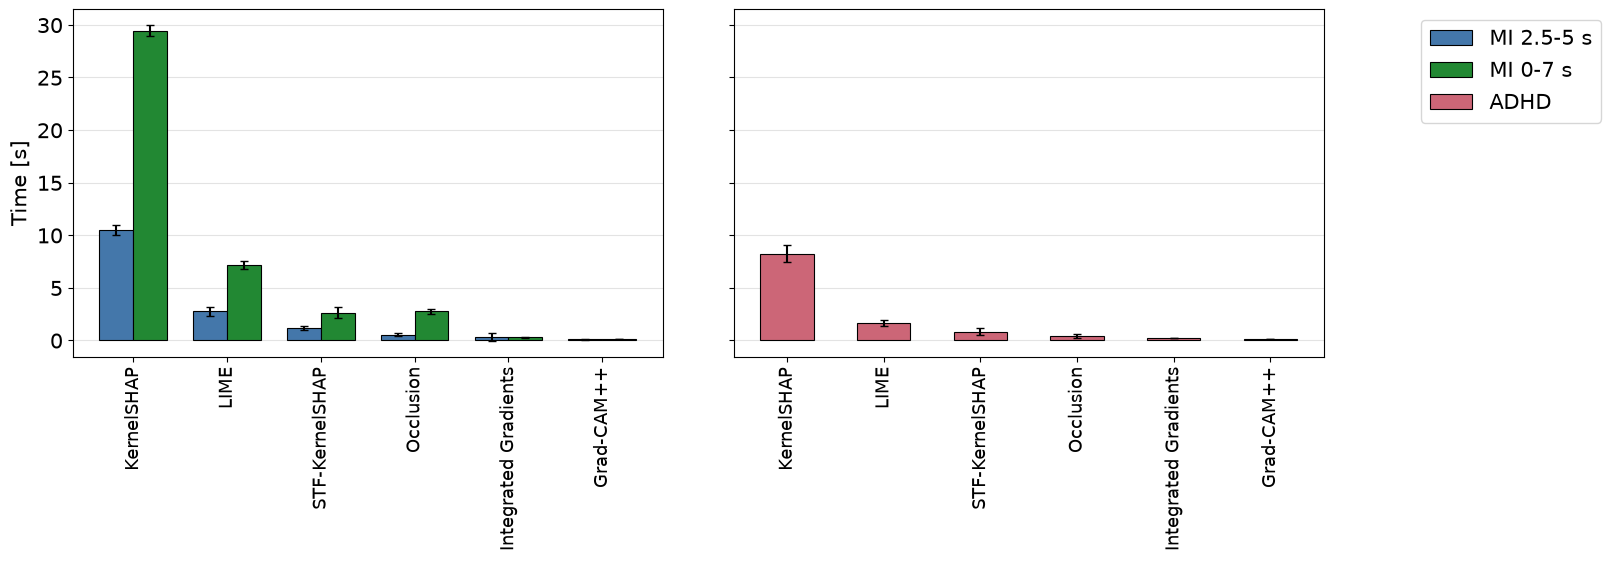

In [21]:
if not timing_log_path.exists():
    raise FileNotFoundError(
        "Timing log was not found. Set OVERWRITE_TIMINGS=True to recompute it, "
        f"or provide an existing log at: {timing_log_path}"
    )

df_timing, df_timing_summary, fig, axes = make_tgarnet_computational_cost_figure(
    timing_log_path=str(timing_log_path),
    save_path=str(FIGURES_DIR / "Computational_cost_scalability.pdf"),
)
display(df_timing_summary)